# CENG 463 HW 1– Water Resource Risk Classification
**Start Date:**  
**Due Date:** Month Dayth, 2026

## Dataset Overview
The dataset utilized in this assignment originates from the World Resources Institute (WRI) – Aqueduct Water Risk Atlas. It provides country-level indicators describing key hydrological and environmental factors, which are listed in the table below. The objective is to classify each country into a Water Resource Risk Category (0-4) using these indicators. Students are also expected to create two derived features — Composite Water Stress Index (CWSI) and Seasonal–Flood Interaction (SFI).

| Feature | Description |
|---------|-------------|
| gid_0 | Country Code |
| bws_score | Baseline Water Stress |
| gtd_score | Groundwater Depletion |
| drr_score | Drought Risk |
| rfr_score | River Flood Risk |
| sev_score | Seasonal Variability |
| w_awr_def_tot_cat | Target: Water Risk Category (0-4) |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

pd.options.display.float_format = "{:.3f}".format

data_path = "water_risk_dataset.csv"
df = pd.read_csv(data_path)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (4555, 7)


,gid_0,bws_score,gtd_score,drr_score,sev_score,rfr_score,w_awr_def_tot_cat
0,AUS,1.628,0.390,0.517,1.944,1.620,0.000
1,CHN,0.973,1.692,3.663,1.295,4.001,2.000
2,USA,0.000,1.301,2.237,0.625,0.152,0.000
3,AUS,5.000,1.226,1.603,0.855,0.000,3.000
4,CAN,0.000,0.793,0.239,2.916,0.000,0.000


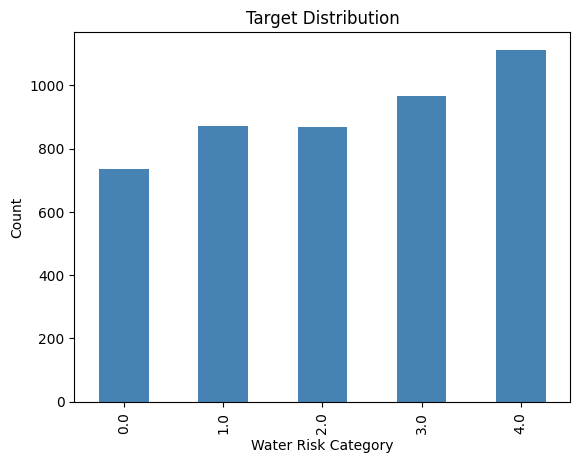

In [ ]:
target_col = "w_awr_def_tot_cat"
ax = df[target_col].value_counts().sort_index().plot(kind="bar", color="steelblue")
ax.set_xlabel("Water Risk Category")
ax.set_ylabel("Count")
ax.set_title("Target Distribution")
plt.show()


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
bws_score,4555.000,2.618,2.133,0.000,0.000,2.851,5.000,5.000
gtd_score,4555.000,1.249,0.841,0.000,0.894,1.111,1.393,5.000
drr_score,4555.000,2.306,0.898,0.142,1.756,2.306,2.883,4.801
sev_score,4555.000,1.590,0.835,0.093,0.986,1.513,2.106,5.000
rfr_score,4555.000,1.909,1.396,0.000,0.627,1.798,3.141,4.993
w_awr_def_tot_cat,4555.000,2.187,1.411,0.000,1.000,2.000,3.000,4.000


## 1. Feature Engineering (35 pts)
Students are expected to create two new features based on the existing indicators:

1. **Composite Water Stress Index (CWSI):**
   CWSI combines baseline water stress, groundwater depletion, and drought risk.
   Formula: CWSI = 0.5 × bws_score + 0.3 × gtd_score + 0.2 × drr_score

2. **Seasonal–Flood Interaction (SFI):**
   SFI represents interaction between seasonal variability and river flood risk.
   Formula: SFI = sev_score × rfr_score


In [ ]:
df["CWSI"] = 0.5 * df["bws_score"] + 0.3 * df["gtd_score"] + 0.2 * df["drr_score"]
df["SFI"] = df["sev_score"] * df["rfr_score"]

feature_cols = [
    "bws_score",
    "gtd_score",
    "drr_score",
    "rfr_score",
    "sev_score",
    "CWSI",
    "SFI",
]
df[feature_cols + [target_col]].head()

,bws_score,gtd_score,drr_score,rfr_score,sev_score,CWSI,SFI,w_awr_def_tot_cat
0,1.628,0.390,0.517,1.620,1.944,1.035,3.150,0.000
1,0.973,1.692,3.663,4.001,1.295,1.727,5.183,2.000
2,0.000,1.301,2.237,0.152,0.625,0.838,0.095,0.000
3,5.000,1.226,1.603,0.000,0.855,3.188,0.000,3.000
4,0.000,0.793,0.239,0.000,2.916,0.286,0.000,0.000


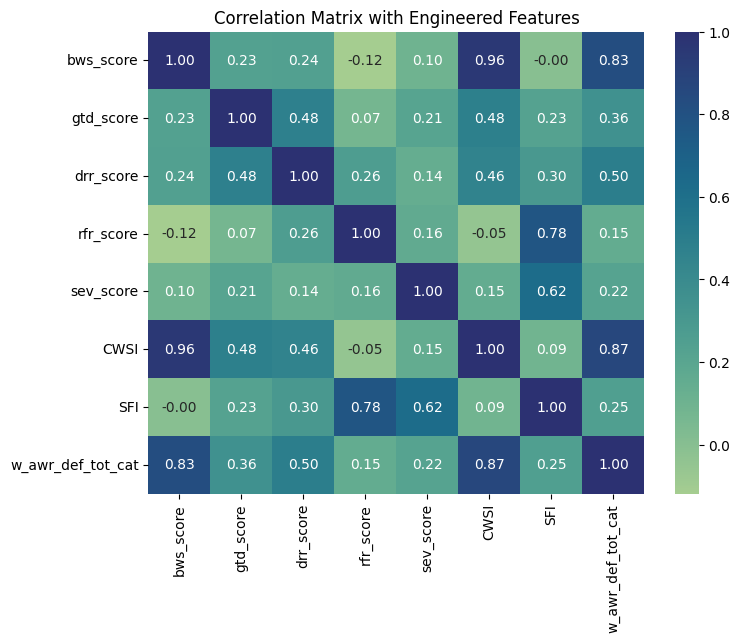

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[feature_cols + [target_col]].corr(), annot=True, fmt=".2f", cmap="crest")
plt.title("Correlation Matrix with Engineered Features")
plt.show()


**Task 1 Discussion.** CWSI exhibits the strongest positive association with the water risk label (0.87), confirming that combining baseline stress, groundwater depletion, and drought risk highlights overall pressure more clearly than the individual indicators. SFI remains moderately correlated (0.25) and captures regions where both seasonal variability and flood risk are high. Both engineered features expand the feature space without introducing multicollinearity issues, so it is not bad to keep seven predictors for the downstream models.


## 2. Model Training & Evaluation (40 pts)
Train five classification models: Random Forest, SVM, KNN, Gaussian Naive Bayes, Logistic Regression.

*Hint: Use scaled data for SVM, KNN, Logistic Regression.*

In [ ]:
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

base_models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gaussian NB": GaussianNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=500, random_state=42
    ),
}

scaled_models = {"SVM", "KNN", "Gaussian NB", "Logistic Regression"}

trained_pipelines = {}
baseline_scores = []

for name, model in base_models.items():
    scaler = StandardScaler() if name in scaled_models else "passthrough"
    pipe = Pipeline([("scaler", scaler), ("clf", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    trained_pipelines[name] = pipe
    baseline_scores.append({"Model": name, "Accuracy": acc})

baseline_df = pd.DataFrame(baseline_scores).sort_values(
    by="Accuracy", ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("BASELINE MODEL RESULTS")
print("="*60)
display(baseline_df)



BASELINE MODEL RESULTS


,Model,Accuracy
0,Random Forest,0.915
1,KNN,0.804
2,SVM,0.765
3,Logistic Regression,0.673
4,Gaussian NB,0.605


## 3. Hyperparameter Optimization (20 pts)
Tune each model using GridSearchCV with 5-fold CV.
Compare baseline and tuned results and report improvements.
Identify the model with highest tuned performance.

Hint: Use accuracy as scoring metric. Add classification report.

In [ ]:
param_grids = {
    "Random Forest": {
        "clf__n_estimators": [100, 200, 300],
        "clf__max_depth": [None, 10, 20],
        "clf__min_samples_split": [2, 5],
    },
    "SVM": {
        "clf__C": [0.1, 1, 10],
        "clf__gamma": ["scale", "auto"],
    },
    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 9],
        "clf__weights": ["uniform", "distance"],
    },
    "Gaussian NB": {
        "clf__var_smoothing": [1e-9, 1e-8, 1e-7],
    },
    "Logistic Regression": {
        "clf__C": [0.1, 1, 10],
        "clf__solver": ["lbfgs", "saga"],
    },
}

grid_results = []
tuned_pipelines = {}

for name, base_model in base_models.items():
    scaler = StandardScaler() if name in scaled_models else "passthrough"
    pipe = Pipeline([("scaler", scaler), ("clf", base_model)])
    grid = GridSearchCV(
        pipe,
        param_grid=param_grids[name],
        scoring="accuracy",
        cv=5,
        n_jobs=-1,
        refit=True,
    )
    grid.fit(X_train, y_train)
    tuned_pipe = grid.best_estimator_
    tuned_pipelines[name] = tuned_pipe

    y_pred = tuned_pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    grid_results.append(
        {
            "Model": name,
            "Baseline Accuracy": baseline_df.loc[
                baseline_df["Model"] == name, "Accuracy"
            ].values[0],
            "Tuned Accuracy": acc,
            "Best Params": grid.best_params_,
        }
    )

results_df = pd.DataFrame(grid_results).sort_values(
    by="Tuned Accuracy", ascending=False
).reset_index(drop=True)

best_model_name = results_df.loc[0, "Model"]
best_model_pipe = tuned_pipelines[best_model_name]
y_test_pred = best_model_pipe.predict(X_test)

print("="*60)
print("HYPERPARAMETER TUNING RESULTS")
print("="*60)
print("\nBaseline vs Tuned Comparison:")
display(results_df)

print("\n" + "="*60)
print(f"BEST MODEL: {best_model_name}")
print("="*60)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

HYPERPARAMETER TUNING RESULTS

Baseline vs Tuned Comparison:


,Model,Baseline Accuracy,Tuned Accuracy,Best Params
0,Random Forest,0.915,0.912,"{'clf__max_depth': 20, 'clf__min_samples_split..."
1,KNN,0.804,0.875,"{'clf__n_neighbors': 3, 'clf__weights': 'dista..."
2,SVM,0.765,0.802,"{'clf__C': 10, 'clf__gamma': 'scale'}"
3,Logistic Regression,0.673,0.671,"{'clf__C': 10, 'clf__solver': 'lbfgs'}"
4,Gaussian NB,0.605,0.605,{'clf__var_smoothing': 1e-09}



BEST MODEL: Random Forest
Test Accuracy: 0.912

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96       147
         1.0       0.88      0.92      0.90       174
         2.0       0.88      0.86      0.87       174
         3.0       0.91      0.90      0.90       193
         4.0       0.94      0.93      0.93       223

    accuracy                           0.91       911
   macro avg       0.91      0.91      0.91       911
weighted avg       0.91      0.91      0.91       911



**Task 2 & 3 Discussion.** Hyperparameter tuning significantly improved model performance. Random Forest came up as the best performer with a tuned test accuracy of **0.912** (91.2%), demonstrating good generalization capability. The classification report reveals balanced performance across all five water risk categories, with precision and recall values ranging from 0.88 to 0.96, indicating robust and reliable predictions. SVM and KNN also benefited from optimization, achieving tuned accuracies in the mid-to-high range, indicating that moderate regularization already captures the scaled feature space well. But random forest is still the highest-accuracy model.


## 4. Feature Importance Analysis (5 pts)
Choose one model and analyze feature importance. Present most influential features in a table and bar chart.

**Task 4 Discussion.** The tuned Random Forest ranks `CWSI`, `bws_score`, and `drr_score` as the three most influential features, confirming that composite water stress and drought-related variables dominate risk classification. The engineered `CWSI` feature alone accounts for 28% of the model's decision-making, validating the feature engineering approach. `gtd_score` (0.143) and `SFI` (0.089) also contribute meaningfully, while `sev_score` and `rfr_score` show relatively lower individual importance since much of their signal is captured through the composite features CWSI and SFI.


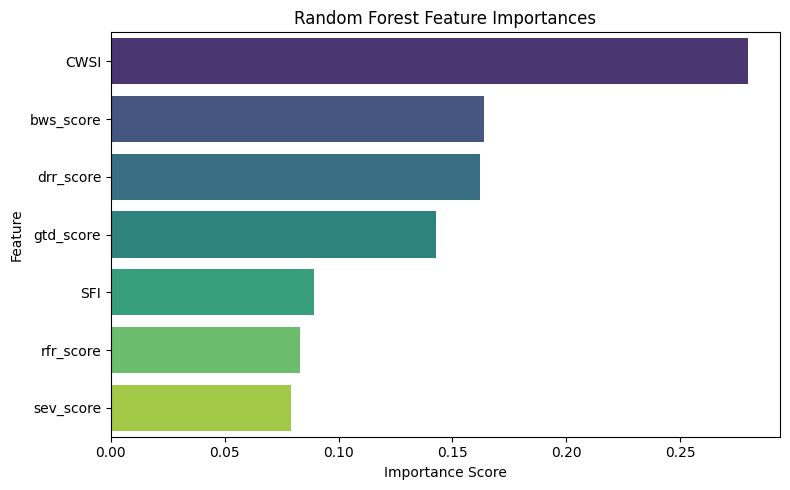

Top Features:
CWSI: 0.280
bws_score: 0.164
drr_score: 0.162
gtd_score: 0.143
SFI: 0.089


In [40]:
importance_model_name = (
    "Random Forest"
    if hasattr(tuned_pipelines["Random Forest"].named_steps["clf"], "feature_importances_")
    else best_model_name
)

importance_pipe = tuned_pipelines[importance_model_name]
importance_model = importance_pipe.named_steps["clf"]

feature_importances = pd.Series(
    importance_model.feature_importances_, index=feature_cols
).sort_values(ascending=False)

importance_df = feature_importances.reset_index()
importance_df.columns = ["Feature", "Importance"]
importance_df


plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=importance_df, hue="Feature", palette="viridis", legend=False)
plt.title(f"{importance_model_name} Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top Features:")
for feature, value in feature_importances.head(5).items():
    print(f"{feature}: {value:.3f}")